In [1]:
!pip install pandas

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import os
os.getcwd()

'/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis'

In [4]:
LOGS_DIR = os.getcwd() + "/../logs/full/"
LOGS_DIR

'/Users/angel/Desktop/prism-games/prism-examples/csgs/learning/analysis/../logs/full/'

In [20]:
files = sorted(Path(LOGS_DIR).glob("*.csv"))
data = [pd.read_csv(f) for f in files]
names = [f.stem for f in files]

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "lines.linewidth": 2,
})

# optional LaTeX (if installed)
plt.rcParams["text.usetex"] = True

In [4]:
metrics = [
    ("deltaT", r"$\Delta_t$"),
    ("maxRadius", "Max radius"),
    ("propUnknown", "Coverage"),
]

num_rows = len(data)
num_cols = len(metrics)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(4*num_cols, 3*num_rows), sharex=True)

if num_rows == 1:
    axes = np.expand_dims(axes, axis=0)

for i, df in enumerate(data):
    for j, (col, label) in enumerate(metrics):
        ax = axes[i, j]

        ax.plot(df["episode"], df[col])

        if col == "deltaT":
            ax.set_yscale("log")

        if i == 0:
            ax.set_title(label)

        if j == 0:
            ax.set_ylabel(names[i])

        if i == num_rows - 1:
            ax.set_xlabel("Episode")

        ax.grid(True)

plt.tight_layout()
plt.show()

NameError: name 'data' is not defined

## Selecting delayed_coord2 for main RQ1a

In [13]:
file_path = Path(LOGS_DIR) / "delayed_coord2/delayed_coord2_41.csv"

In [14]:
df = pd.read_csv(file_path)
# df['coverage'] = 1 - df["numUnknownSlots"] / df["numUnknownSlots"].max()
df['coverage'] = 1 - df["propUnknown"]

In [15]:
df['radiusRatio'] = df['avgRadius'] / df['maxRadius']

In [16]:
df

,episode,deltaT,maxRadius,avgRadius,numUnknownSlots,propUnknown,numSamples,totalNumSamples,coverage,radiusRatio
0,1,25.00,2.000,2.000000,20,1.0,5,5,0.0,1.000000
1,11,25.00,2.000,1.521595,20,1.0,9,84,0.0,0.760798
2,21,25.00,2.000,1.290877,20,1.0,10,182,0.0,0.645438
3,31,25.00,2.000,1.188407,20,1.0,11,291,0.0,0.594204
4,41,25.00,2.000,1.117569,20,1.0,12,404,0.0,0.558785
...,...,...,...,...,...,...,...,...,...,...
2036649,20366491,0.05,0.004,0.001667,4,0.2,38,730424917,0.8,0.416848
2036650,20366501,0.05,0.004,0.001667,4,0.2,38,730425297,0.8,0.416848
2036651,20366511,0.05,0.004,0.001667,4,0.2,38,730425677,0.8,0.416848
2036652,20366521,0.05,0.004,0.001667,4,0.2,38,730426057,0.8,0.416848


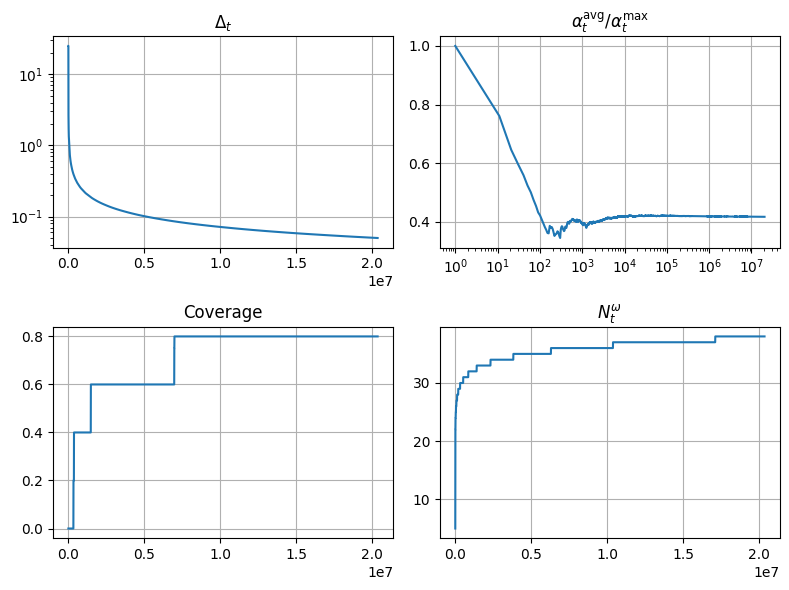

In [17]:
metrics = [
    ("deltaT", r"$\Delta_t$"),
    ("radiusRatio", r"$\alpha_t^{\mathrm{avg}} / \alpha_t^{\max}$"),
    ("coverage", "Coverage"),
    ("numSamples", r"$N^\omega_t$")
]

fig, axes = plt.subplots(2, len(metrics)//2, figsize=(2*len(metrics), 2*3))
axes = axes.flatten()

for j, (col, label) in enumerate(metrics):
    ax = axes[j]
    # if col == "radius":
    #     ax.plot(df["episode"], df["maxRadius"], label="Max")
    #     ax.plot(df["episode"], df["avgRadius"], label="Avg")
    #     ax.legend()
    # else:
    ax.plot(df["episode"], df[col])

    if col == "deltaT":
        ax.set_yscale("log")
    elif col == "radiusRatio":
        ax.set_xscale("log")  
        # ax.set_xlabel(r"$\log{t}$")

    ax.set_title(label)
    # ax.set_xlabel("$t$")
    ax.grid(True)


plt.tight_layout()
plt.savefig(
    "delayed_coord2_learning.pdf",
    bbox_inches="tight",
    dpi=300
)

plt.show()
plt.close()

1. $\Delta_t$: sharp drop early, then slow decay -> Early exploration eliminates high uncertainty quickly. Later phase is statistical refinement
2. **Radius ratio**:
   - fast decay initially, non-monotonic decrease; noisy, non-smooth
   - worst-case $(s,a)$ (maybe the ones with low transition probability to them) are significantly less explored than typical ones
   - exploration is non-uniform and bottlenecked by rare states 
   - delayed_coord's multi-step coordination structure stresses this
3. coverage: step-like increase, plateau < 1 -> not all $(s,a)$ are known (perhaps due to finite-horizon property, but the $\Delta_t$ stopping condition is expected to happen before allSlotsKnown)
5. numSamples increases steeply early, but latter stabilises (with small increase due to allocation of $\confCov$

In [12]:
def learning_plot(fname):
    file_path = Path(LOGS_DIR) / fname
    df = pd.read_csv(file_path)
    df['coverage'] = 1 - df["numUnknownSlots"] / df["numUnknownSlots"].max()
    df['radiusRatio'] = df['avgRadius'] / df['maxRadius']

    metrics = [
        ("deltaT", r"$\Delta_t$"),
        ("radiusRatio", r"$\alpha_t^{\mathrm{avg}} / \alpha_t^{\max}$"),
        ("coverage", "Coverage"),
        ("numSamples", r"$N^\omega_t$")
    ]
    
    fig, axes = plt.subplots(2, len(metrics)//2, figsize=(2*len(metrics), 2*3))
    axes = axes.flatten()
    
    for j, (col, label) in enumerate(metrics):
        ax = axes[j]
        ax.plot(df["episode"], df[col])
    
        if col == "deltaT":
            ax.set_yscale("log")
        elif col == "radiusRatio":
            ax.set_xscale("log")  
            # ax.set_xlabel(r"$\log{t}$")
    
        ax.set_title(label)
        # ax.set_xlabel("$t$")
        ax.grid(True)
    
    
    plt.tight_layout()
    plt.savefig(Path(fname).stem + ".pdf",
        bbox_inches="tight",
        dpi=300
    )

    plt.show()
    plt.close

In [ ]:
learning_plot("delayed_coord1.csv")

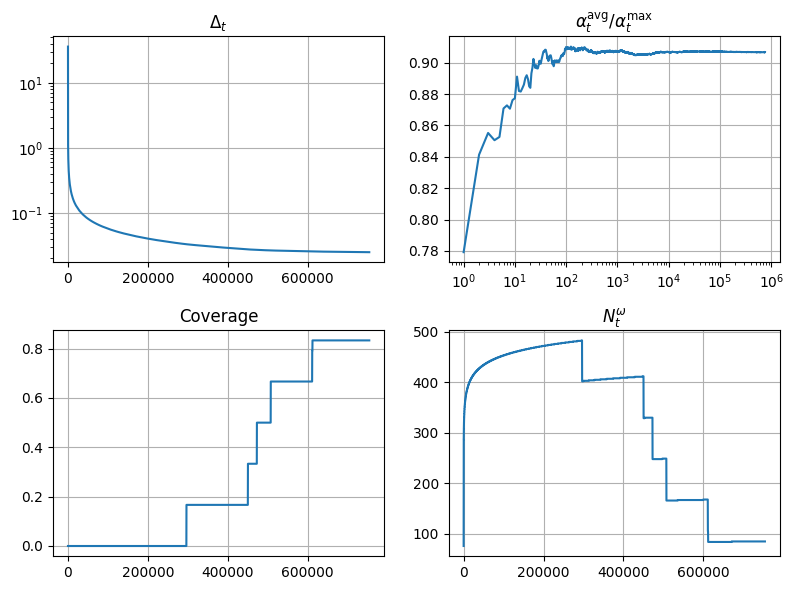

<Figure size 640x480 with 0 Axes>

In [5]:
learning_plot("traffic_merge1.csv")
# max radius decays faster than avg radius -> analyse game structure

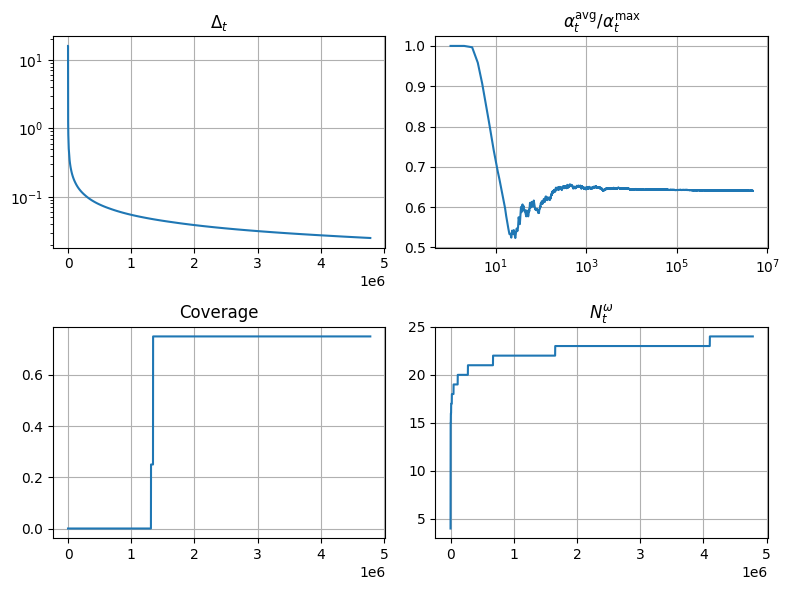

<Figure size 640x480 with 0 Axes>

In [7]:
learning_plot("mixed_ne1.csv")